# Orange County  & LA Public Health Analysis

Using open\-source data from Melissa: https://drive\.google\.com/drive/folders/1hFZEL\-Ad95UiIRwMqq8uhFVOEVySG7oj?usp=drive\_link

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
asthma_rates = pd.read_csv("asthma/Asthma_Rates_OC.csv")
cig_rate = pd.read_csv("asthma/Cigarette_Smoking_Rates.csv")
mental_distress = pd.read_csv("asthma/Mental_Distress_Rates.csv")
zip_codes_df = pd.read_csv("ZipDataCamel.csv")

In [3]:
zip_codes_df_dropped = zip_codes_df.drop(['State', 'Latitude', 'Longitude','DominantAreaCode', 'ResidentialPOBoxes',
                    'BusinessPOBoxes', 'LastLineIndicator'], axis=1, inplace=False)

# Asthma Data Dataset:

from https://data\.cdc\.gov/500\-Cities\-Places/PLACES\-Local\-Data\-for\-Better\-Health\-ZCTA\-Data\-2025/qnzd\-25i4/explore/query/SELECT%0A%20%20%60year%60%2C%0A%20%20%60locationname%60%2C%0A%20%20%60datasource%60%2C%0A%20%20%60category%60%2C%0A%20%20%60measure%60%2C%0A%20%20%60data\_value\_unit%60%2C%0A%20%20%60data\_value\_type%60%2C%0A%20%20%60data\_value%60%2C%0A%20%20%60data\_value\_footnote\_symbol%60%2C%0A%20%20%60data\_value\_footnote%60%2C%0A%20%20%60low\_confidence\_limit%60%2C%0A%20%20%60high\_confidence\_limit%60%2C%0A%20%20%60totalpop18plus%60%2C%0A%20%20%60totalpopulation%60%2C%0A%20%20%60geolocation%60%2C%0A%20%20%60locationid%60%2C%0A%20%20%60categoryid%60%2C%0A%20%20%60measureid%60%2C%0A%20%20%60datavaluetypeid%60%2C%0A%20%20%60short\_question\_text%60%0AWHERE%0A%20%20caseless\_one\_of%28%60category%60%2C%20%22Health%20Status%22%29%0A%20%20AND%20caseless\_starts\_with%28%60locationname%60%2C%20%229%22%29%0A%20%20AND%20caseless\_one\_of%28%60year%60%2C%20%222023%22%29%0A%20%20AND%20caseless\_one\_of%28%0A%20%20%20%20%60measure%60%2C%0A%20%20%20%20%22Fair%20or%20poor%20self\-rated%20health%20status%20among%20adults%22%0A%20%20%29/page/filter

In [4]:
asthma_rates

,Year,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPop18plus,TotalPopulation,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2023,90001,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,9.9,NaN,NaN,9.0,10.9,"39,428","55,859",POINT (-118.2490388 33.9736648),90001,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
1,2023,90002,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,10.6,NaN,NaN,9.6,11.6,"37,021","53,150",POINT (-118.2467796 33.9489868),90002,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
2,2023,90003,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,10.7,NaN,NaN,9.7,11.8,"50,744","72,764",POINT (-118.2727831 33.9641307),90003,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
3,2023,90004,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,8.8,NaN,NaN,8.0,9.7,"48,418","58,585",POINT (-118.3109634 34.0762187),90004,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
4,2023,90005,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,8.7,NaN,NaN,7.8,9.5,"32,095","37,987",POINT (-118.3089617 34.0593736),90005,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3055,2023,99922,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,13.1,NaN,NaN,11.5,14.8,273,380,POINT (-133.0468153 55.3075279),99922,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
3056,2023,99923,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,9.3,NaN,NaN,8.1,10.5,55,66,POINT (-130.0374737 56.0005181),99923,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
3057,2023,99925,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,12.0,NaN,NaN,10.6,13.6,611,784,POINT (-132.9459473 55.550203),99925,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
3058,2023,99926,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,13.7,NaN,NaN,12.1,15.4,"1,126","1,562",POINT (-131.4704246 55.1383523),99926,HLTHOUT,CASTHMA,CrdPrv,Current Asthma


In [5]:
asthma_rates_cleaned = asthma_rates[["LocationName", "Data_Value"]]

asthma_rates_cleaned = asthma_rates_cleaned.rename(columns={"LocationName": "ZipCode",
                                                    "Data_Value": "PctAsthma"})
                                                    
asthma_rates_cleaned["PctAsthma"] = asthma_rates_cleaned["PctAsthma"]/100

asthma_rates_cleaned

,ZipCode,PctAsthma
0,90001,0.099
1,90002,0.106
2,90003,0.107
3,90004,0.088
4,90005,0.087
...,...,...
3055,99922,0.131
3056,99923,0.093
3057,99925,0.120
3058,99926,0.137


In [6]:
cig_rate_cleaned = cig_rate[["LocationName", "Data_Value"]]

cig_rate_cleaned = cig_rate_cleaned.rename(columns={"LocationName": "ZipCode",
                                                    "Data_Value": "PctCigSmoke"})

cig_rate_cleaned["PctCigSmoke"] = cig_rate_cleaned["PctCigSmoke"]/100

cig_rate_cleaned

,ZipCode,PctCigSmoke
0,90001,0.162
1,90002,0.169
2,90003,0.180
3,90004,0.122
4,90005,0.133
...,...,...
3055,99922,0.264
3056,99923,0.103
3057,99925,0.211
3058,99926,0.255


In [7]:

mental_distress

,Year,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPop18plus,TotalPopulation,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2023,90001,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,20.8,NaN,NaN,19.2,22.5,"39,428","55,859",POINT (-118.2490388 33.9736648),90001,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
1,2023,90002,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,21.4,NaN,NaN,19.8,23.2,"37,021","53,150",POINT (-118.2467796 33.9489868),90002,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
2,2023,90003,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,22.0,NaN,NaN,20.2,23.7,"50,744","72,764",POINT (-118.2727831 33.9641307),90003,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
3,2023,90004,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,16.9,NaN,NaN,15.5,18.4,"48,418","58,585",POINT (-118.3109634 34.0762187),90004,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
4,2023,90005,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,17.2,NaN,NaN,15.8,18.7,"32,095","37,987",POINT (-118.3089617 34.0593736),90005,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3055,2023,99922,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,18.4,NaN,NaN,16.0,20.9,273,380,POINT (-133.0468153 55.3075279),99922,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
3056,2023,99923,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,13.2,NaN,NaN,11.4,15.3,55,66,POINT (-130.0374737 56.0005181),99923,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
3057,2023,99925,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,16.5,NaN,NaN,14.5,18.7,611,784,POINT (-132.9459473 55.550203),99925,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
3058,2023,99926,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,19.5,NaN,NaN,17.2,22.0,"1,126","1,562",POINT (-131.4704246 55.1383523),99926,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress


In [8]:

mental_distress_cleaned = mental_distress[["LocationName", "Data_Value"]]

mental_distress_cleaned = mental_distress_cleaned.rename(columns={"LocationName": "ZipCode",
                                                    "Data_Value": "PctMentalDistress"})
                                                    
mental_distress_cleaned["PctMentalDistress"] = mental_distress_cleaned["PctMentalDistress"]/100

mental_distress_cleaned

,ZipCode,PctMentalDistress
0,90001,0.208
1,90002,0.214
2,90003,0.220
3,90004,0.169
4,90005,0.172
...,...,...
3055,99922,0.184
3056,99923,0.132
3057,99925,0.165
3058,99926,0.195


# Dataset Merge & Visualizations:

In [9]:
zip_codes_df_dropped["EducationPreHSGrad"] = zip_codes_df_dropped["EducationNinthGradeOrLess"] + zip_codes_df_dropped["EducationSomeHighSchool"]
zip_codes_df_dropped["EducationPostHSGrad"] = zip_codes_df_dropped["EducationHighSchoolGraduate"] + zip_codes_df_dropped["EducationSomeCollegeWithoutDiploma"] + zip_codes_df_dropped["EducationAssociatesDegree"] + zip_codes_df_dropped["EducationBachelorsDegree"]
zip_codes_df_dropped = zip_codes_df_dropped.drop(["EducationNinthGradeOrLess", "EducationSomeHighSchool", "EducationHighSchoolGraduate", "EducationSomeCollegeWithoutDiploma", "EducationAssociatesDegree", "EducationBachelorsDegree"], axis=1, inplace=False)

In [10]:
df_tent = pd.merge(zip_codes_df_dropped, asthma_rates_cleaned, on="ZipCode", how="inner")
df_tent

,RecordID,ZipCode,City,County,ResidentialDeliveries,BusinessDeliveries,TotalPopulation,PopulationWhite,PopulationAfricanAmerican,PopulationAmericanIndianAlaskaNative,...,PopulationMultipleRace,MedianHouseholdIncome,PerCapitaIncome,MedianHomeValue,MedianAge,MedianAgeMale,MedianAgeFemale,EducationPreHSGrad,EducationPostHSGrad,PctAsthma
0,1,90001,Firestone Park,Los Angeles,13443,1466,58245,20030,4799,1196,...,5876,52806.0,16530.0,617000.0,30.7,30.9,30.5,18338,21666,0.099
1,2,90001,Los Angeles,Los Angeles,13443,1466,58245,20030,4799,1196,...,5876,52806.0,16530.0,617000.0,30.7,30.9,30.5,18338,21666,0.099
2,3,90002,Los Angeles,Los Angeles,12443,452,54384,17275,9256,1893,...,5707,46159.0,15998.0,606000.0,28.9,28.2,29.6,16423,20927,0.106
3,4,90002,Watts,Los Angeles,12443,452,54384,17275,9256,1893,...,5707,46159.0,15998.0,606000.0,28.9,28.2,29.6,16423,20927,0.106
4,5,90003,Broadway Manchester,Los Angeles,18149,1634,75190,16669,12865,709,...,10544,47733.0,15605.0,625000.0,29.0,27.7,30.5,22804,27563,0.107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,700,93553,Pearblossom,Los Angeles,355,9,1056,847,5,0,...,79,59805.0,39151.0,371000.0,62.1,63.2,59.4,121,835,0.103
695,701,93563,Pearblossom,Los Angeles,4,1,247,143,50,4,...,37,210600.0,26648.0,462000.0,31.1,34.5,3.6,38,131,0.082
696,702,93563,Valyermo,Los Angeles,4,1,247,143,50,4,...,37,210600.0,26648.0,462000.0,31.1,34.5,3.6,38,131,0.082
697,703,93591,Lake Los Angeles,Los Angeles,2121,53,6914,3495,402,15,...,1034,53733.0,21006.0,369000.0,32.1,38.4,28.5,1341,3357,0.102


In [11]:
df_tent2 = pd.merge(df_tent, cig_rate_cleaned, on="ZipCode", how="inner")
df_tent2

,RecordID,ZipCode,City,County,ResidentialDeliveries,BusinessDeliveries,TotalPopulation,PopulationWhite,PopulationAfricanAmerican,PopulationAmericanIndianAlaskaNative,...,MedianHouseholdIncome,PerCapitaIncome,MedianHomeValue,MedianAge,MedianAgeMale,MedianAgeFemale,EducationPreHSGrad,EducationPostHSGrad,PctAsthma,PctCigSmoke
0,1,90001,Firestone Park,Los Angeles,13443,1466,58245,20030,4799,1196,...,52806.0,16530.0,617000.0,30.7,30.9,30.5,18338,21666,0.099,0.162
1,2,90001,Los Angeles,Los Angeles,13443,1466,58245,20030,4799,1196,...,52806.0,16530.0,617000.0,30.7,30.9,30.5,18338,21666,0.099,0.162
2,3,90002,Los Angeles,Los Angeles,12443,452,54384,17275,9256,1893,...,46159.0,15998.0,606000.0,28.9,28.2,29.6,16423,20927,0.106,0.169
3,4,90002,Watts,Los Angeles,12443,452,54384,17275,9256,1893,...,46159.0,15998.0,606000.0,28.9,28.2,29.6,16423,20927,0.106,0.169
4,5,90003,Broadway Manchester,Los Angeles,18149,1634,75190,16669,12865,709,...,47733.0,15605.0,625000.0,29.0,27.7,30.5,22804,27563,0.107,0.180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,700,93553,Pearblossom,Los Angeles,355,9,1056,847,5,0,...,59805.0,39151.0,371000.0,62.1,63.2,59.4,121,835,0.103,0.137
695,701,93563,Pearblossom,Los Angeles,4,1,247,143,50,4,...,210600.0,26648.0,462000.0,31.1,34.5,3.6,38,131,0.082,0.121
696,702,93563,Valyermo,Los Angeles,4,1,247,143,50,4,...,210600.0,26648.0,462000.0,31.1,34.5,3.6,38,131,0.082,0.121
697,703,93591,Lake Los Angeles,Los Angeles,2121,53,6914,3495,402,15,...,53733.0,21006.0,369000.0,32.1,38.4,28.5,1341,3357,0.102,0.168


In [12]:
df = pd.merge(df_tent2, mental_distress_cleaned, on="ZipCode", how="inner")
df.drop(["City", "RecordID", "ResidentialDeliveries", "BusinessDeliveries"], axis=1, inplace=True)
df.drop_duplicates(inplace=True)
for ethnicity in ("White", "AfricanAmerican", "AmericanIndianAlaskaNative",
                 "Asian", "Hispanic", "Other", "MultipleRace"):
    df.insert(len(df.columns), f"Pct{ethnicity}", df[f"Population{ethnicity}"] / df["TotalPopulation"])

df.insert(len(df.columns), "PctEducationPreHSGrad", df["EducationPreHSGrad"] / df["TotalPopulation"])
df.insert(len(df.columns), "PctEducationPostHSGrad", df["EducationPostHSGrad"] / df["TotalPopulation"])


df

,ZipCode,County,TotalPopulation,PopulationWhite,PopulationAfricanAmerican,PopulationAmericanIndianAlaskaNative,PopulationAsian,PopulationHispanic,PopulationPacificIslander,PopulationOther,...,PctMentalDistress,PctWhite,PctAfricanAmerican,PctAmericanIndianAlaskaNative,PctAsian,PctHispanic,PctOther,PctMultipleRace,PctEducationPreHSGrad,PctEducationPostHSGrad
0,90001,Los Angeles,58245,20030,4799,1196,293,52765,70,25981,...,0.208,0.343892,0.082393,0.020534,0.005030,0.905915,0.446064,0.100884,0.314842,0.371980
2,90002,Los Angeles,54384,17275,9256,1893,627,44082,75,19551,...,0.214,0.317649,0.170197,0.034808,0.011529,0.810569,0.359499,0.104939,0.301982,0.384801
4,90003,Los Angeles,75190,16669,12865,709,384,60929,45,33974,...,0.220,0.221692,0.171100,0.009429,0.005107,0.810334,0.451842,0.140231,0.303285,0.366578
6,90004,Los Angeles,59621,17681,2448,446,15224,28019,104,19907,...,0.169,0.296557,0.041059,0.007481,0.255346,0.469952,0.333892,0.063920,0.175207,0.551215
8,90005,Los Angeles,36910,7616,2180,325,12212,18134,18,10302,...,0.172,0.206340,0.059063,0.008805,0.330859,0.491303,0.279111,0.115335,0.225305,0.520022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,93551,Los Angeles,54808,28860,5544,337,4312,22848,196,9328,...,0.167,0.526565,0.101153,0.006149,0.078675,0.416873,0.170194,0.113688,0.106846,0.564772
692,93552,Los Angeles,43118,19035,5250,573,1088,29762,13,13101,...,0.185,0.441463,0.121759,0.013289,0.025233,0.690245,0.303841,0.094114,0.158913,0.521221
693,93553,Los Angeles,1056,847,5,0,10,176,0,115,...,0.178,0.802083,0.004735,0.000000,0.009470,0.166667,0.108902,0.074811,0.114583,0.790720
695,93563,Los Angeles,247,143,50,4,4,61,0,9,...,0.166,0.578947,0.202429,0.016194,0.016194,0.246964,0.036437,0.149798,0.153846,0.530364


In [13]:
df.to_csv("smoke_datathon.csv")

# Predictive Modeling

Predicting asthma rate with predictors: PctCigSmoke, PctMentalDistress, demographic, age, education, household income

In [56]:
from sklearn.model_selection import train_test_split

#computing features that highly correlate with asthma rates
correlations_asthma = df.drop(["ZipCode", "PerCapitaIncome", "MedianHomeValue",
                                "PopulationWhite", "PopulationAfricanAmerican",
                                "PopulationAmericanIndianAlaskaNative", "PopulationAsian",
                                "PopulationHispanic", "PopulationPacificIslander",
                                "PopulationOther", "PopulationMultipleRace",
                                "EducationPostHSGrad", "EducationPreHSGrad"], axis=1).corr(numeric_only=True)["PctAsthma"]

correlations_asthma

TotalPopulation                 -0.011387
MedianHouseholdIncome           -0.264705
MedianAge                       -0.223446
MedianAgeMale                   -0.220244
MedianAgeFemale                 -0.176894
PctAsthma                        1.000000
PctCigSmoke                      0.380233
PctMentalDistress                0.642471
PctWhite                         0.215679
PctAfricanAmerican               0.531271
PctAmericanIndianAlaskaNative    0.058927
PctAsian                        -0.719613
PctHispanic                      0.109620
PctOther                         0.057249
PctMultipleRace                  0.093912
PctEducationPreHSGrad            0.104508
PctEducationPostHSGrad           0.052985
Name: PctAsthma, dtype: float64

In [20]:
!pip install xgboost==3.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 39.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Test Model Performance:
Test RMSE: 0.0038
Test R²: 0.6914


<Figure size 1000x600 with 0 Axes>

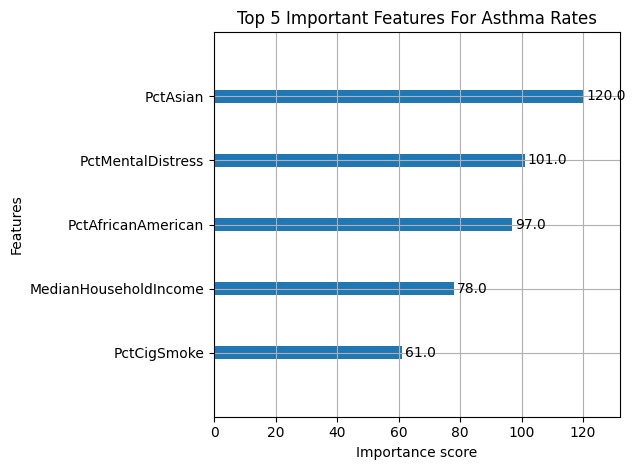

In [22]:
from xgboost import plot_importance
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

top5_features_asthma = correlations_asthma.transform(lambda x: x * x).drop("PctAsthma").sort_values(ascending=False).head(5).index.tolist()


X_asthma = df[top5_features_asthma]
y_asthma = df["PctAsthma"]

X_asthma_train, X_asthma_test, y_asthma_train, y_asthma_test = train_test_split(
    X_asthma, y_asthma, test_size=0.2, random_state=1111)


model = XGBRegressor(random_state=111)
model.fit(X_asthma_train, y_asthma_train)

y_asthma_pred = model.predict(X_asthma_test)
rmse = mean_squared_error(y_asthma_test, y_asthma_pred) ** 0.5
r2 = r2_score(y_asthma_test, y_asthma_pred)

print("Test Model Performance:")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=5)
plt.title("Top 5 Important Features For Asthma Rates")
plt.tight_layout()
plt.show()
#PopulationAsian & MedianHouseholdIncome are negative corelations

## Model for Smoking Prevalance:

In [24]:
#computing features that highly correlate with smoking rates
correlations_cigsmoke = df.drop(["ZipCode", "PerCapitaIncome", "MedianHomeValue",
                                "PopulationWhite", "PopulationAfricanAmerican",
                                "PopulationAmericanIndianAlaskaNative", "PopulationAsian",
                                "PopulationHispanic", "PopulationPacificIslander",
                                "PopulationOther", "PopulationMultipleRace",
                                "EducationPostHSGrad", "EducationPreHSGrad"], axis=1).corr(numeric_only=True)["PctCigSmoke"]

correlations_cigsmoke

TotalPopulation                  0.281500
MedianHouseholdIncome           -0.787512
MedianAge                       -0.323494
MedianAgeMale                   -0.321727
MedianAgeFemale                 -0.383203
PctAsthma                        0.380233
PctCigSmoke                      1.000000
PctMentalDistress                0.670336
PctWhite                        -0.421623
PctAfricanAmerican               0.319416
PctAmericanIndianAlaskaNative    0.429933
PctAsian                        -0.281096
PctHispanic                      0.653725
PctOther                         0.615513
PctMultipleRace                  0.135244
PctEducationPreHSGrad            0.818977
PctEducationPostHSGrad          -0.357441
Name: PctCigSmoke, dtype: float64

Test Model Performance:
Test RMSE: 0.0187
Test R²: 0.6594


<Figure size 1000x600 with 0 Axes>

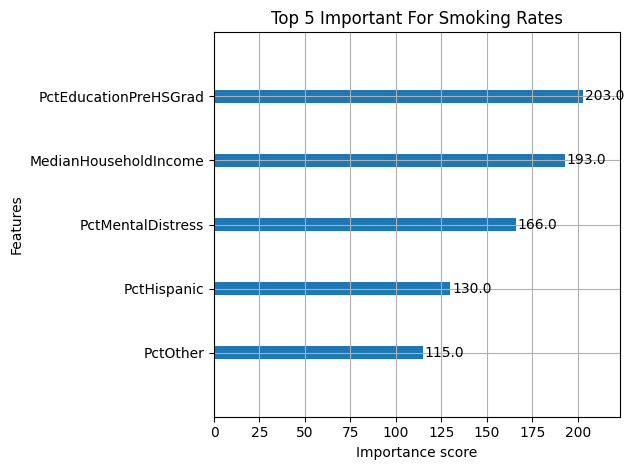

In [26]:
top5_features_smoking = correlations_cigsmoke.transform(lambda x: x * x).drop("PctCigSmoke").sort_values(ascending=False).head(5).index.tolist()


X_cigsmoke_small = df[top5_features_smoking]
y_cigsmoke = df["PctCigSmoke"]

X_cigsmoke_train, X_cigsmoke_test, y_cigsmoke_train, y_cigsmoke_test = train_test_split(
    X_cigsmoke_small, y_cigsmoke, test_size=0.2, random_state=1111)



model = XGBRegressor(random_state=111)
model.fit(X_cigsmoke_train, y_cigsmoke_train)

y_cigsmoke_pred = model.predict(X_cigsmoke_test)
rmse = mean_squared_error(y_cigsmoke_test, y_cigsmoke_pred) ** 0.5
r2 = r2_score(y_cigsmoke_test, y_cigsmoke_pred)

print("Test Model Performance:")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=5)
plt.title("Top 5 Important For Smoking Rates")
plt.tight_layout()
plt.show()
#MedianHouseholdIncome is a negative corelations

# LA Only Analysis

In [50]:
df

,ZipCode,County,TotalPopulation,PopulationWhite,PopulationAfricanAmerican,PopulationAmericanIndianAlaskaNative,PopulationAsian,PopulationHispanic,PopulationPacificIslander,PopulationOther,...,PctMentalDistress,PctWhite,PctAfricanAmerican,PctAmericanIndianAlaskaNative,PctAsian,PctHispanic,PctOther,PctMultipleRace,PctEducationPreHSGrad,PctEducationPostHSGrad
0,90001,Los Angeles,58245,20030,4799,1196,293,52765,70,25981,...,0.208,0.343892,0.082393,0.020534,0.005030,0.905915,0.446064,0.100884,0.314842,0.371980
2,90002,Los Angeles,54384,17275,9256,1893,627,44082,75,19551,...,0.214,0.317649,0.170197,0.034808,0.011529,0.810569,0.359499,0.104939,0.301982,0.384801
4,90003,Los Angeles,75190,16669,12865,709,384,60929,45,33974,...,0.220,0.221692,0.171100,0.009429,0.005107,0.810334,0.451842,0.140231,0.303285,0.366578
6,90004,Los Angeles,59621,17681,2448,446,15224,28019,104,19907,...,0.169,0.296557,0.041059,0.007481,0.255346,0.469952,0.333892,0.063920,0.175207,0.551215
8,90005,Los Angeles,36910,7616,2180,325,12212,18134,18,10302,...,0.172,0.206340,0.059063,0.008805,0.330859,0.491303,0.279111,0.115335,0.225305,0.520022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,93551,Los Angeles,54808,28860,5544,337,4312,22848,196,9328,...,0.167,0.526565,0.101153,0.006149,0.078675,0.416873,0.170194,0.113688,0.106846,0.564772
692,93552,Los Angeles,43118,19035,5250,573,1088,29762,13,13101,...,0.185,0.441463,0.121759,0.013289,0.025233,0.690245,0.303841,0.094114,0.158913,0.521221
693,93553,Los Angeles,1056,847,5,0,10,176,0,115,...,0.178,0.802083,0.004735,0.000000,0.009470,0.166667,0.108902,0.074811,0.114583,0.790720
695,93563,Los Angeles,247,143,50,4,4,61,0,9,...,0.166,0.578947,0.202429,0.016194,0.016194,0.246964,0.036437,0.149798,0.153846,0.530364


In [58]:

#computing features that highly correlate with asthma rates
correlations_asthma_la = df.loc[df["County"]=="Los Angeles"].drop(["ZipCode", "PerCapitaIncome", "MedianHomeValue",
                                "PopulationWhite", "PopulationAfricanAmerican",
                                "PopulationAmericanIndianAlaskaNative", "PopulationAsian",
                                "PopulationHispanic", "PopulationPacificIslander",
                                "PopulationOther", "PopulationMultipleRace",
                                "EducationPostHSGrad", "EducationPreHSGrad"], axis=1).corr(numeric_only=True)["PctAsthma"]

correlations_asthma_la

TotalPopulation                  0.003589
MedianHouseholdIncome           -0.342213
MedianAge                       -0.300578
MedianAgeMale                   -0.298756
MedianAgeFemale                 -0.234735
PctAsthma                        1.000000
PctCigSmoke                      0.423234
PctMentalDistress                0.687932
PctWhite                         0.153464
PctAfricanAmerican               0.572645
PctAmericanIndianAlaskaNative    0.039101
PctAsian                        -0.714908
PctHispanic                      0.119765
PctOther                         0.061535
PctMultipleRace                  0.087855
PctEducationPreHSGrad            0.136116
PctEducationPostHSGrad           0.007058
Name: PctAsthma, dtype: float64

Test Model Performance:
Test RMSE: 0.0038
Test R²: 0.6914


<Figure size 1000x600 with 0 Axes>

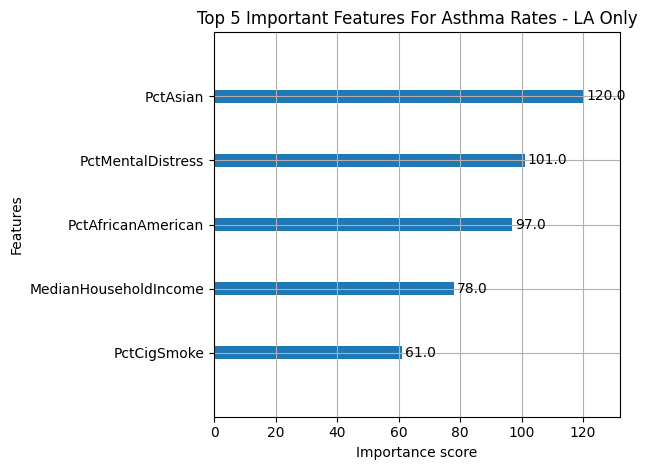

In [60]:
top5_features_asthma_la = correlations_asthma_la.transform(lambda x: x * x).drop("PctAsthma").sort_values(ascending=False).head(5).index.tolist()


X_asthma_la = df[top5_features_asthma_la]
y_asthma_la = df["PctAsthma"]

X_asthma_la_train, X_asthma_la_test, y_asthma_la_train, y_asthma_la_test = train_test_split(
    X_asthma_la, y_asthma_la, test_size=0.2, random_state=1111)


model = XGBRegressor(random_state=111)
model.fit(X_asthma_la_train, y_asthma_la_train)

y_asthma_la_pred = model.predict(X_asthma_la_test)
rmse = mean_squared_error(y_asthma_la_test, y_asthma_la_pred) ** 0.5
r2 = r2_score(y_asthma_la_test, y_asthma_la_pred)

print("Test Model Performance:")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=5)
plt.title("Top 5 Important Features For Asthma Rates - LA Only")
plt.tight_layout()
plt.show()

SInce our data is so LA centric, this is the same as the previous model

In [86]:
#computing features that highly correlate with smoking rates
correlations_cigsmoke_la = df.loc[df["County"]=="Los Angeles"].drop(["ZipCode", "PerCapitaIncome", "MedianHomeValue",
                                "PopulationWhite", "PopulationAfricanAmerican",
                                "PopulationAmericanIndianAlaskaNative", "PopulationAsian",
                                "PopulationHispanic", "PopulationPacificIslander",
                                "PopulationOther", "PopulationMultipleRace",
                                "EducationPostHSGrad", "EducationPreHSGrad"], axis=1).corr(numeric_only=True)["PctCigSmoke"]

correlations_cigsmoke_la

TotalPopulation                  0.279317
MedianHouseholdIncome           -0.785604
MedianAge                       -0.268726
MedianAgeMale                   -0.272491
MedianAgeFemale                 -0.344257
PctAsthma                        0.423234
PctCigSmoke                      1.000000
PctMentalDistress                0.675254
PctWhite                        -0.361694
PctAfricanAmerican               0.276053
PctAmericanIndianAlaskaNative    0.415813
PctAsian                        -0.318816
PctHispanic                      0.614274
PctOther                         0.573577
PctMultipleRace                  0.112008
PctEducationPreHSGrad            0.800815
PctEducationPostHSGrad          -0.372392
Name: PctCigSmoke, dtype: float64

Test Model Performance:
Test RMSE: 0.0187
Test R²: 0.6594


<Figure size 1000x600 with 0 Axes>

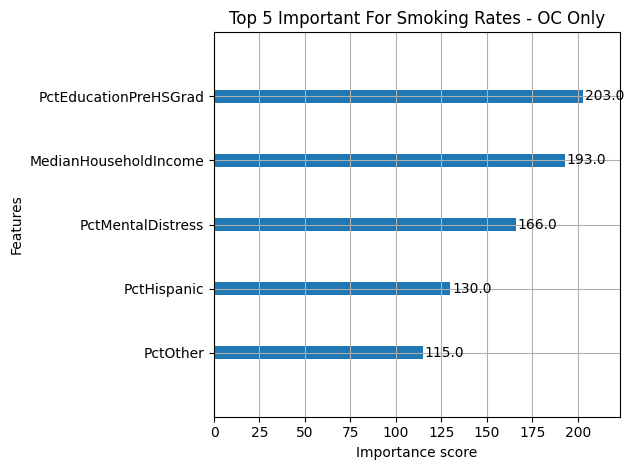

In [88]:
top5_features_cigsmoke_la = correlations_cigsmoke_la.transform(lambda x: x * x).drop("PctCigSmoke").sort_values(ascending=False).head(5).index.tolist()


X_cigsmoke_la_small = df[top5_features_cigsmoke_la]
y_cigsmoke_la = df["PctCigSmoke"]

X_cigsmoke_la_train, X_cigsmoke_la_test, y_cigsmoke_la_train, y_cigsmoke_la_test = train_test_split(
    X_cigsmoke_la_small, y_cigsmoke_la, test_size=0.2, random_state=1111)



model = XGBRegressor(random_state=111)
model.fit(X_cigsmoke_la_train, y_cigsmoke_la_train)

y_cigsmoke_la_pred = model.predict(X_cigsmoke_la_test)
rmse = mean_squared_error(y_cigsmoke_la_test, y_cigsmoke_la_pred) ** 0.5
r2 = r2_score(y_cigsmoke_la_test, y_cigsmoke_la_pred)

print("Test Model Performance:")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=5)
plt.title("Top 5 Important For Smoking Rates - OC Only")
plt.tight_layout()
plt.show()
#MedianHouseholdIncome is a negative corelations

# OC Only

In [66]:
correlations_asthma_oc = df.loc[df["County"]=="Orange"].drop(["ZipCode", "PerCapitaIncome", "MedianHomeValue",
                                "PopulationWhite", "PopulationAfricanAmerican",
                                "PopulationAmericanIndianAlaskaNative", "PopulationAsian",
                                "PopulationHispanic", "PopulationPacificIslander",
                                "PopulationOther", "PopulationMultipleRace",
                                "EducationPostHSGrad", "EducationPreHSGrad"], axis=1).corr(numeric_only=True)["PctAsthma"]

correlations_asthma_oc

TotalPopulation                 -0.088280
MedianHouseholdIncome            0.079566
MedianAge                        0.106747
MedianAgeMale                    0.107375
MedianAgeFemale                  0.086003
PctAsthma                        1.000000
PctCigSmoke                      0.079818
PctMentalDistress                0.369946
PctWhite                         0.670129
PctAfricanAmerican               0.028085
PctAmericanIndianAlaskaNative    0.153054
PctAsian                        -0.837595
PctHispanic                      0.003337
PctOther                        -0.018445
PctMultipleRace                  0.116021
PctEducationPreHSGrad           -0.146699
PctEducationPostHSGrad           0.414223
Name: PctAsthma, dtype: float64

Test Model Performance:
Test RMSE: 0.0031
Test R²: 0.8039


<Figure size 1000x600 with 0 Axes>

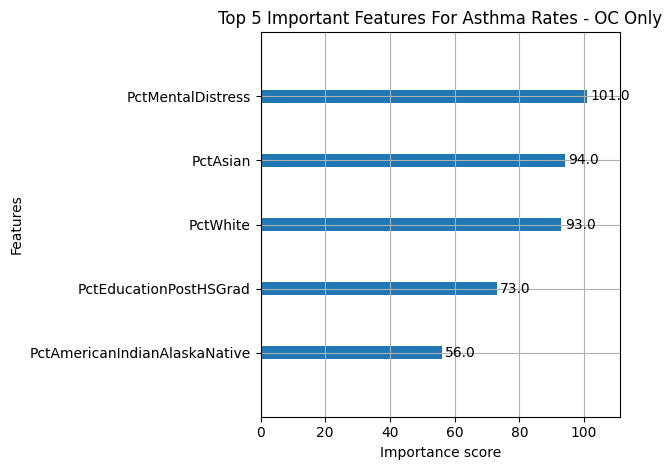

In [70]:
top5_features_asthma_oc = correlations_asthma_oc.transform(lambda x: x * x).drop("PctAsthma").sort_values(ascending=False).head(5).index.tolist()


X_asthma_oc = df[top5_features_asthma_oc]
y_asthma_oc = df["PctAsthma"]

X_asthma_oc_train, X_asthma_oc_test, y_asthma_oc_train, y_asthma_oc_test = train_test_split(
    X_asthma_oc, y_asthma_oc, test_size=0.2, random_state=1111)


model = XGBRegressor(random_state=111)
model.fit(X_asthma_oc_train, y_asthma_oc_train)

y_asthma_oc_pred = model.predict(X_asthma_oc_test)
rmse = mean_squared_error(y_asthma_oc_test, y_asthma_oc_pred) ** 0.5
r2 = r2_score(y_asthma_oc_test, y_asthma_oc_pred)

print("Test Model Performance:")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=5)
plt.title("Top 5 Important Features For Asthma Rates - OC Only")
plt.tight_layout()
plt.show()

#

In [82]:
#computing features that highly correlate with smoking rates
correlations_cigsmoke_oc = df.loc[df["County"]=="Orange"].drop(["ZipCode", "PerCapitaIncome", "MedianHomeValue",
                                "PopulationWhite", "PopulationAfricanAmerican",
                                "PopulationAmericanIndianAlaskaNative", "PopulationAsian",
                                "PopulationHispanic", "PopulationPacificIslander",
                                "PopulationOther", "PopulationMultipleRace",
                                "EducationPostHSGrad", "EducationPreHSGrad"], axis=1).corr(numeric_only=True)["PctCigSmoke"]

correlations_cigsmoke_oc

TotalPopulation                  0.444176
MedianHouseholdIncome           -0.719284
MedianAge                       -0.489583
MedianAgeMale                   -0.462867
MedianAgeFemale                 -0.492479
PctAsthma                        0.079818
PctCigSmoke                      1.000000
PctMentalDistress                0.753566
PctWhite                        -0.555115
PctAfricanAmerican               0.174465
PctAmericanIndianAlaskaNative    0.335185
PctAsian                         0.066507
PctHispanic                      0.776117
PctOther                         0.711066
PctMultipleRace                  0.132064
PctEducationPreHSGrad            0.890956
PctEducationPostHSGrad          -0.278759
Name: PctCigSmoke, dtype: float64

Test Model Performance:
Test RMSE: 0.0171
Test R²: 0.7144


<Figure size 1000x600 with 0 Axes>

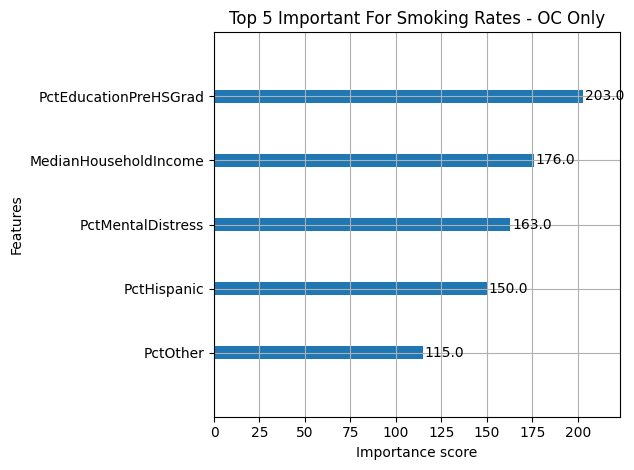

In [84]:
top5_features_cigsmoke_oc = correlations_cigsmoke_oc.transform(lambda x: x * x).drop("PctCigSmoke").sort_values(ascending=False).head(5).index.tolist()


X_cigsmoke_oc_small = df[top5_features_cigsmoke_oc]
y_cigsmoke_oc = df["PctCigSmoke"]

X_cigsmoke_oc_train, X_cigsmoke_oc_test, y_cigsmoke_oc_train, y_cigsmoke_oc_test = train_test_split(
    X_cigsmoke_oc_small, y_cigsmoke_oc, test_size=0.2, random_state=1111)



model = XGBRegressor(random_state=111)
model.fit(X_cigsmoke_oc_train, y_cigsmoke_oc_train)

y_cigsmoke_oc_pred = model.predict(X_cigsmoke_oc_test)
rmse = mean_squared_error(y_cigsmoke_oc_test, y_cigsmoke_oc_pred) ** 0.5
r2 = r2_score(y_cigsmoke_oc_test, y_cigsmoke_oc_pred)

print("Test Model Performance:")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=5)
plt.title("Top 5 Important For Smoking Rates - OC Only")
plt.tight_layout()
plt.show()
#MedianHouseholdIncome is a negative corelations

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=cc43e4b7-6001-48ea-8159-145328a9eb1f' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>